## 판다스 기초

### 판다스 패키지 로드

import pandas as pd


In [7]:
import pandas as pd

In [8]:
# DataFrame을 직접 생성할때 사용.
# 파이썬 딕셔너리 사용
raw_data = {
    'name' : ['홍길동','김철수','이영희','박민수','성유고','애슐리'],
    'age' : [20,21,22,23,30,29],
    'major' : ['데이터분석', '웹개발', '인공지능','임베디드','인공지능','웹개발'],
    'score' : [85,90,95,80,90,100]
}
raw_data

{'name': ['홍길동', '김철수', '이영희', '박민수', '성유고', '애슐리'],
 'age': [20, 21, 22, 23, 30, 29],
 'major': ['데이터분석', '웹개발', '인공지능', '임베디드', '인공지능', '웹개발'],
 'score': [85, 90, 95, 80, 90, 100]}

In [9]:
df = pd.DataFrame(raw_data)

df

,name,age,major,score
0,홍길동,20,데이터분석,85
1,김철수,21,웹개발,90
2,이영희,22,인공지능,95
3,박민수,23,임베디드,80
4,성유고,30,인공지능,90
5,애슐리,29,웹개발,100


#### 기본통계

In [10]:
# 숫자타입 필드만 통계 가능
df.describe()

,age,score
count,6.000000,6.000000
mean,24.166667,90.000000
std,4.262237,7.071068
min,20.000000,80.000000
25%,21.250000,86.250000
50%,22.500000,90.000000
75%,27.500000,93.750000
max,30.000000,100.000000


#### 컬럼(열) 선택

In [12]:
# DataFrame에서 필요한 컬럼만 확인 또는 할당 (복사)
df['name']

0    홍길동
1    김철수
2    이영희
3    박민수
4    성유고
5    애슐리
Name: name, dtype: str

- DataFrame에서 하나의 컬럼만 가져오면 `Series` 타입이 됨
  (Series(1차원) 묶음은 DataFrame(2차원))

In [13]:
# 컬럼 선택의 편의성으로 추가된 방식 위와 동일
df.name

0    홍길동
1    김철수
2    이영희
3    박민수
4    성유고
5    애슐리
Name: name, dtype: str

In [14]:
# 대괄호가 두개인지 하나인지로 시리즈와 데이터프레임을 구분
df[['name','age']]

,name,age
0,홍길동,20
1,김철수,21
2,이영희,22
3,박민수,23
4,성유고,30
5,애슐리,29


In [15]:
# . 으로 만들면 시리즈형태로 출력됨(df를 만드는 방법은 없음-대괄호 사용필요)
df.name, df.age

(0    홍길동
 1    김철수
 2    이영희
 3    박민수
 4    성유고
 5    애슐리
 Name: name, dtype: str,
 0    20
 1    21
 2    22
 3    23
 4    30
 5    29
 Name: age, dtype: int64)

#### 로우(행) 선택

In [16]:
# 인덱스 이름을 기준으로 행을 출력
df.loc[0]

name       홍길동
age         20
major    데이터분석
score       85
Name: 0, dtype: object

In [17]:
# 인덱스 위치번호. 인덱스를 다른 값으로 바꿨을때 사용하는 방법
df.iloc[0]

name       홍길동
age         20
major    데이터분석
score       85
Name: 0, dtype: object

In [21]:
# 시리즈의 인덱스로 각 열의 값을 확인
df.loc[0]['name']

'홍길동'

In [22]:
# 슬라이싱으로 여러행을 선택
# df는 파이썬의 슬라이싱 규칙에서 벗어남. 뒤의 수가 n-1이 아님!!
df.loc[0:2]

,name,age,major,score
0,홍길동,20,데이터분석,85
1,김철수,21,웹개발,90
2,이영희,22,인공지능,95


In [23]:
data = [1,2,3,4,5]

In [24]:
data[0:2]

[1, 2]

In [25]:
df.iloc[0:2]

,name,age,major,score
0,홍길동,20,데이터분석,85
1,김철수,21,웹개발,90


#### 행 선택, 인덱스행(loc)과 위치값행(iloc)차이

In [26]:
df2 = pd.DataFrame(raw_data,
                   index=['S0001','S0002','S0003','S0005','S0009','S0010'])

df2

,name,age,major,score
S0001,홍길동,20,데이터분석,85
S0002,김철수,21,웹개발,90
S0003,이영희,22,인공지능,95
S0005,박민수,23,임베디드,80
S0009,성유고,30,인공지능,90
S0010,애슐리,29,웹개발,100


In [30]:
df2.loc['S0002':'S0005']

,name,age,major,score
S0002,김철수,21,웹개발,90
S0003,이영희,22,인공지능,95
S0005,박민수,23,임베디드,80


In [32]:
df2.iloc['S0002']

TypeError: Cannot index by location index with a non-integer key

In [33]:
# 파이썬 배열 인덱스와 동일
df2.iloc[2]

name      이영희
age        22
major    인공지능
score      95
Name: S0003, dtype: object

- loc는 부여받은 인덱스로 행을 선택하거나 슬라이싱
- iloc는 원래부터 있는 위치값(파이썬 배열의 인덱스)

#### 행과 열을 함께 선택

In [35]:
df.loc[0,'name']

'홍길동'

In [37]:
#인덱스를 따로 부여하지 않은 df에서 행과 열 선택
df.loc[0:2, ['name','age']]

,name,age
0,홍길동,20
1,김철수,21
2,이영희,22


In [42]:
#인덱스를 부여한 df에서 행과 열 선택
df2.loc['S0001':'S0003', ['name','age']]

,name,age
S0001,홍길동,20
S0002,김철수,21
S0003,이영희,22


In [44]:
df3 = df2.loc['S0001':'S0003', ['name','age']]

df3 # 새 DataFrame 생성

,name,age
S0001,홍길동,20
S0002,김철수,21
S0003,이영희,22


#### 조건 조회
- SQL의 WHERE 절과 동일

In [46]:
df

,name,age,major,score
0,홍길동,20,데이터분석,85
1,김철수,21,웹개발,90
2,이영희,22,인공지능,95
3,박민수,23,임베디드,80
4,성유고,30,인공지능,90
5,애슐리,29,웹개발,100


In [45]:
df['score'] >= 90

0    False
1     True
2     True
3    False
4     True
5     True
Name: score, dtype: bool

In [47]:
df[df['score'] >= 90]

,name,age,major,score
1,김철수,21,웹개발,90
2,이영희,22,인공지능,95
4,성유고,30,인공지능,90
5,애슐리,29,웹개발,100


- Numpy와 동일한 조건 연산
- 파이썬은 : and, or, not 사용
- Numpy, Pandas : `&` , `|` , `~`사용
- 연산자 우선순위로 각 조건은 반드시 `()`를 사용할 것

In [48]:
# 점수가 90점 초과이고 나이가 21살 이상인 학생 데이터 참/거짓 여부
(df['score'] > 90) & (df['age'] >= 21)

0    False
1    False
2     True
3    False
4    False
5     True
dtype: bool

In [49]:
df[(df['score'] > 90) & (df['age'] >= 21)]

,name,age,major,score
2,이영희,22,인공지능,95
5,애슐리,29,웹개발,100


In [50]:
# 점수가 90점 초과이거나 나이가 21살 이상이거나 둘 중 하나가 참인 데이터 조회
df[(df['score'] > 90) | (df['age'] >= 21)]

,name,age,major,score
1,김철수,21,웹개발,90
2,이영희,22,인공지능,95
3,박민수,23,임베디드,80
4,성유고,30,인공지능,90
5,애슐리,29,웹개발,100


#### 컬럼 추가
- 사용하던 DF 이외의 필요한 컬럼이 생길때 추가

In [51]:
df

,name,age,major,score
0,홍길동,20,데이터분석,85
1,김철수,21,웹개발,90
2,이영희,22,인공지능,95
3,박민수,23,임베디드,80
4,성유고,30,인공지능,90
5,애슐리,29,웹개발,100


In [ ]:
# 80점을 초과하는 사람만 통과
# 같은 이름의 컬럼은 중복으로 추가 안됨
df['pass'] = df['score'] > 80

In [53]:
df

,name,age,major,score,pass
0,홍길동,20,데이터분석,85,True
1,김철수,21,웹개발,90,True
2,이영희,22,인공지능,95,True
3,박민수,23,임베디드,80,False
4,성유고,30,인공지능,90,True
5,애슐리,29,웹개발,100,True


In [55]:
df['score_bonus'] = df['score'] + 5

df

,name,age,major,score,pass,score_bonus
0,홍길동,20,데이터분석,85,True,90
1,김철수,21,웹개발,90,True,95
2,이영희,22,인공지능,95,True,100
3,박민수,23,임베디드,80,False,85
4,성유고,30,인공지능,90,True,95
5,애슐리,29,웹개발,100,True,105


#### 컬럼 수정

- 기존 컬럼 수정

In [61]:
df['score_bonus'] = df['score_bonus'] -2

df

,name,age,major,score,pass,score_bonus
0,홍길동,20,데이터분석,85,True,86
1,김철수,21,웹개발,90,True,91
2,이영희,22,인공지능,95,True,96
3,박민수,23,임베디드,80,False,81
4,성유고,30,인공지능,90,True,91
5,애슐리,29,웹개발,100,True,101


In [62]:
# 행선택에서 scorue_bonus 점수가 100점이 넘는 행만 선택 후, score_bonus 열의 값은 100으로 수정
df.loc[df['score_bonus'] > 100, 'score_bonus'] = 100

df

,name,age,major,score,pass,score_bonus
0,홍길동,20,데이터분석,85,True,86
1,김철수,21,웹개발,90,True,91
2,이영희,22,인공지능,95,True,96
3,박민수,23,임베디드,80,False,81
4,성유고,30,인공지능,90,True,91
5,애슐리,29,웹개발,100,True,100


#### 행 추가 

- 새로운 행 추가 방법

In [72]:
df.loc[6] = ['최지우', 24, '웹개발' , 88, True]

In [73]:
df.loc[7] = ['박선호', 25, '인공지능' , 91, None]

In [74]:
df

,name,age,major,score,pass
0,홍길동,20,데이터분석,85,True
1,김철수,21,웹개발,90,True
2,이영희,22,인공지능,95,True
3,박민수,23,임베디드,80,False
4,성유고,30,인공지능,90,True
5,애슐리,29,웹개발,100,True
6,최지우,24,웹개발,88,True
7,박선호,25,인공지능,91,None


#### 컬럼 삭제 

- 불필요한 컬럼은 삭제

In [63]:
# drop은 보이지 않게만 실행됨. 실제 삭제까지 처리안됨
df.drop(columns=['score_bonus'])

,name,age,major,score,pass
0,홍길동,20,데이터분석,85,True
1,김철수,21,웹개발,90,True
2,이영희,22,인공지능,95,True
3,박민수,23,임베디드,80,False
4,성유고,30,인공지능,90,True
5,애슐리,29,웹개발,100,True


In [64]:
df

,name,age,major,score,pass,score_bonus
0,홍길동,20,데이터분석,85,True,86
1,김철수,21,웹개발,90,True,91
2,이영희,22,인공지능,95,True,96
3,박민수,23,임베디드,80,False,81
4,성유고,30,인공지능,90,True,91
5,애슐리,29,웹개발,100,True,100


In [66]:
# 두번실행하면 에러남 컬럼이 없어졌기때문에. 완전히 삭제하려면 inpalce = True 사용
df.drop(columns=['score_bonus'], inplace = True)

KeyError: "['score_bonus'] not found in axis"

In [67]:
df

,name,age,major,score,pass
0,홍길동,20,데이터분석,85,True
1,김철수,21,웹개발,90,True
2,이영희,22,인공지능,95,True
3,박민수,23,임베디드,80,False
4,성유고,30,인공지능,90,True
5,애슐리,29,웹개발,100,True


In [75]:
# 결측치 찾을때 사용
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    8 non-null      str   
 1   age     8 non-null      int64 
 2   major   8 non-null      str   
 3   score   8 non-null      int64 
 4   pass    7 non-null      object
dtypes: int64(2), object(1), str(2)
memory usage: 452.0+ bytes


#### 데이터 읽기 쓰기 

- 일반적으로 CSV(text파일) 가장 많이 사용, excel, txt
- DB도 연동 가능  예. data.go.kr(공공데이터포털)

In [76]:
df_bookstores = pd.read_csv('../data/부산지역서점.csv')

df_bookstores

,연번,시설명,전화번호,시군구,위도,경도,정렬번호
0,0,동사서독,0507-1396-1606,부산 금정구 금정로 87 2층,35.232421,129.086648,67
1,1,흰돌서점,051-625-9633,부산 수영구 남천서로32번길 38 흰돌서점,35.145707,129.106685,1
2,2,효원도서,051-517-6871,부산 금정구 부산대학로 63 (장전동),35.231481,129.084427,2
3,3,화명서점,051-337-0140,부산 북구 화명신도시로 130 로얄팰리스 110호 화명서점,35.235544,129.011331,3
4,4,현대서점,051-581-7963,부산 금정구 남산로 30 현대서점 (남산동),35.267302,129.088872,4
...,...,...,...,...,...,...,...
62,62,책과아이들,051-506-1448,부산 연제구 교대로16번길 20,35.196453,129.078185,62
63,63,책마을,051-753-8685,부산 연제구 안연로8번길 19 3층,35.188471,129.102055,63
64,64,카프카의 밤,051-665-5516,부산 연제구 고분로191번길 20,35.186167,129.104129,64
65,65,동네책방 아인,051-665-5516,부산 연제구 월드컵대로 221 다우빌딩 2층,35.188866,129.072650,65


In [77]:
# 데이터 쓰기
df.to_csv('../data/학생정보.csv', encoding='utf-8')

인코딩할때 사용한 언어 utf-8
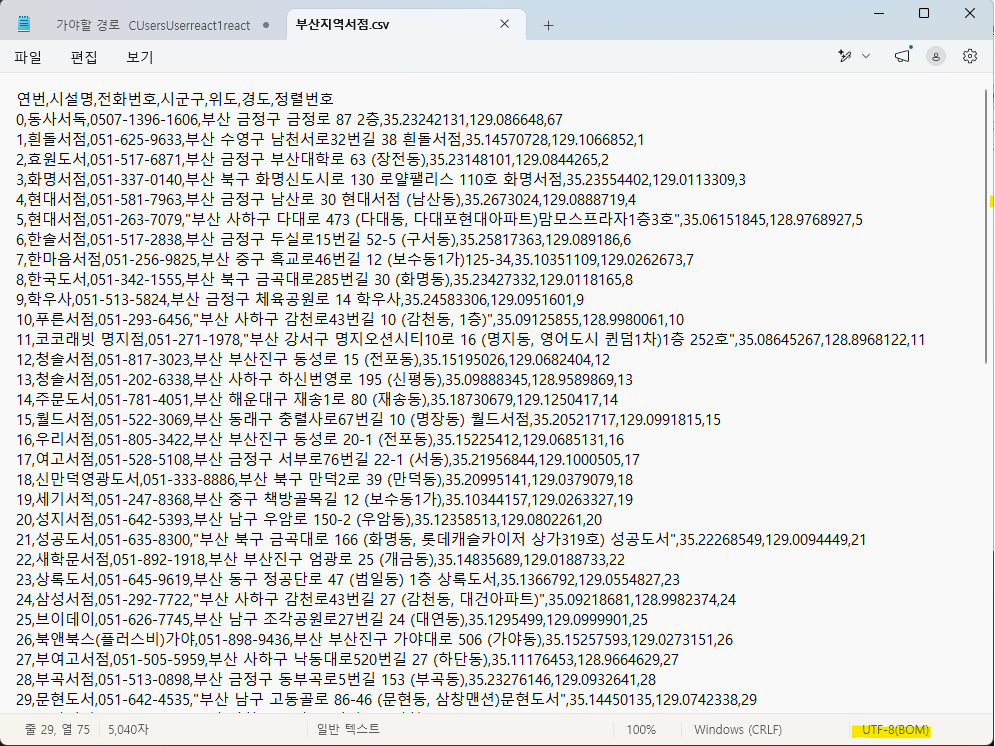

#### Excel

In [79]:
df_bookstores2 =pd.read_excel('../data/부산지역서점.xlsx')

df_bookstores2

,연번,시설명,전화번호,시군구,위도,경도,정렬번호
0,0,동사서독,0507-1396-1606,부산 금정구 금정로 87 2층,35.232421,129.086648,67
1,1,흰돌서점,051-625-9633,부산 수영구 남천서로32번길 38 흰돌서점,35.145707,129.106685,1
2,2,효원도서,051-517-6871,부산 금정구 부산대학로 63 (장전동),35.231481,129.084427,2
3,3,화명서점,051-337-0140,부산 북구 화명신도시로 130 로얄팰리스 110호 화명서점,35.235544,129.011331,3
4,4,현대서점,051-581-7963,부산 금정구 남산로 30 현대서점 (남산동),35.267302,129.088872,4
...,...,...,...,...,...,...,...
62,62,책과아이들,051-506-1448,부산 연제구 교대로16번길 20,35.196453,129.078185,62
63,63,책마을,051-753-8685,부산 연제구 안연로8번길 19 3층,35.188471,129.102055,63
64,64,카프카의 밤,051-665-5516,부산 연제구 고분로191번길 20,35.186167,129.104129,64
65,65,동네책방 아인,051-665-5516,부산 연제구 월드컵대로 221 다우빌딩 2층,35.188866,129.072650,65


#### PostgreSQL

-psycopg

In [80]:
import psycopg

In [82]:
conn = psycopg.connect(
    host ='localhost',
    port=5432,
    dbname='ai_db',
    user='postgres',
    password='123456'
)

In [83]:
sql = 'select * from students'

df_postgres_students = pd.read_sql(sql, conn)

df_postgres_students

C:\Users\User\AppData\Local\Temp\ipykernel_19648\3672862669.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_postgres_students = pd.read_sql(sql, conn)


,id,name,email,age,major,created_at
0,1,김철수,kim@example.com,21,인공지능,2026-09-17 15:52:31.048515
1,2,이영희,lee@example.com,22,데이터분석,2026-09-17 15:52:31.048515
2,3,박민수,park@example.com,23,웹개발,2026-09-17 15:52:31.048515
3,4,최지훈,choi@example.com,24,임베디드,2026-09-17 15:52:31.048515
4,5,정수빈,jung@example.com,20,클라우드,2026-09-17 15:52:31.048515
5,6,주예찬,joo@example.com,24,인공지능,2026-09-18 10:40:46.508722
6,7,이찬혁,lee@example.com,26,임베디드,2026-09-18 10:40:46.508722
7,8,애슐리,ashely@gmail.com,30,영어영문,2026-09-22 12:11:16.995288
8,11,홍길동,hong@gmail.com,30,정치학과,2026-09-22 16:56:24.053494
9,13,홍길동,hong@kakao.com,20,정치학과,2026-09-22 16:59:14.534388


- PostgreSQL로 데이터 저장은 추후 ... 

#### 실습
- 상품데이터 활용

In [86]:
data = {
    'product' : ['키보드', '마우스', '모니터', 'USB', '노트북'],
    'category' : ['주변기기', '주변기기', '디스플레이', '저장장치','컴퓨터'],
    'price' : [30000,15000,250000,12000,1200000],
    'stock' : [10,30,5,50,3]
}

df_procucts = pd.DataFrame(data)

1. 전체 데이터 출력
2. product, price 컬럼 출력
3. 가격이 50000원이상인 상품만 출력
4. 재고가 10개 이상인 상품만 출력
5. total_value 컬럼 추가. 계산식은 price * stock
6. 전체 재고의 합계 출력
7. 카테고리가 주변기기인 상품만 출력

In [ ]:
# 1번
df_procucts

,product,category,price,stock
0,키보드,주변기기,30000,10
1,마우스,주변기기,15000,30
2,모니터,디스플레이,250000,5
3,USB,저장장치,12000,50
4,노트북,컴퓨터,1200000,3


In [89]:
# 2번
df_procucts[['product', 'price']]

,product,price
0,키보드,30000
1,마우스,15000
2,모니터,250000
3,USB,12000
4,노트북,1200000


In [ ]:
#3번
df_procucts['price'] > 50000

0    False
1    False
2     True
3    False
4     True
Name: price, dtype: bool

In [91]:
df_procucts[df_procucts['price'] > 50000]

,product,category,price,stock
2,모니터,디스플레이,250000,5
4,노트북,컴퓨터,1200000,3


In [92]:
#4번
df_procucts['stock'] >= 10

0     True
1     True
2    False
3     True
4    False
Name: stock, dtype: bool

In [93]:
df_procucts[df_procucts['stock'] >= 10]

,product,category,price,stock
0,키보드,주변기기,30000,10
1,마우스,주변기기,15000,30
3,USB,저장장치,12000,50


In [ ]:
#5번
df_procucts['totla_value'] = df_procucts['price'] * df_procucts['stock']

df_procucts

,product,category,price,stock,totla_value
0,키보드,주변기기,30000,10,300000
1,마우스,주변기기,15000,30,450000
2,모니터,디스플레이,250000,5,1250000
3,USB,저장장치,12000,50,600000
4,노트북,컴퓨터,1200000,3,3600000


In [98]:
#6번
df_procucts['totla_value'].sum()

np.int64(6200000)

In [100]:
df_procucts[df_procucts['category'] == '주변기기']

,product,category,price,stock,totla_value
0,키보드,주변기기,30000,10,300000
1,마우스,주변기기,15000,30,450000


In [101]:
df_procucts.to_excel('../data/상품정보.xlsx')